Epoch 01 | Loss 0.646 | Train 0.621 | Val 0.674 | LR 0.00100 | 0.1s
Epoch 02 | Loss 0.584 | Train 0.734 | Val 0.739 | LR 0.00099 | 0.1s
Epoch 03 | Loss 0.522 | Train 0.779 | Val 0.739 | LR 0.00098 | 0.1s
Epoch 04 | Loss 0.498 | Train 0.796 | Val 0.754 | LR 0.00096 | 0.1s
Epoch 05 | Loss 0.520 | Train 0.799 | Val 0.746 | LR 0.00093 | 0.1s
Epoch 06 | Loss 0.483 | Train 0.801 | Val 0.739 | LR 0.00090 | 0.0s
Epoch 07 | Loss 0.433 | Train 0.804 | Val 0.739 | LR 0.00087 | 0.1s
Epoch 08 | Loss 0.509 | Train 0.808 | Val 0.739 | LR 0.00083 | 0.1s
Epoch 09 | Loss 0.467 | Train 0.815 | Val 0.746 | LR 0.00079 | 0.1s
Early stopping at epoch 9

Best validation: 0.7536


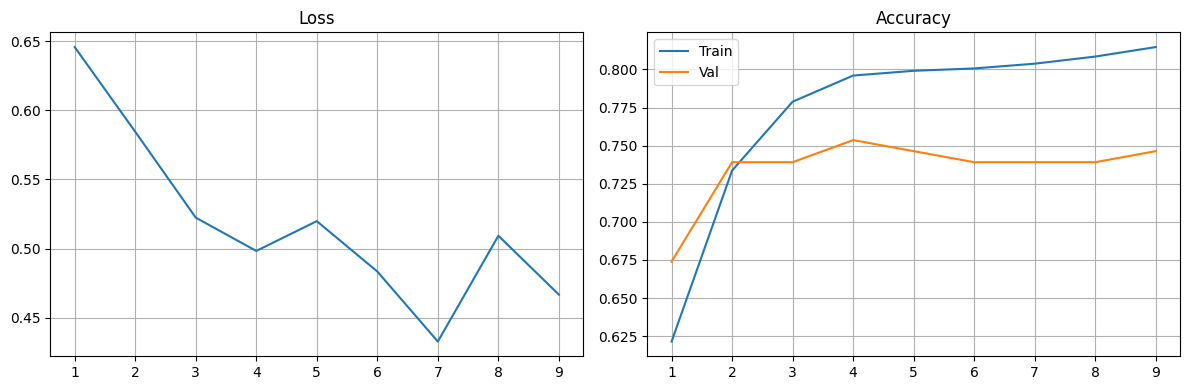


Test Accuracy: 0.7899


In [11]:
import time
import copy
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics.classification import BinaryAccuracy


df = pd.read_csv('cleanned.csv')

cat_cols = ['sex', 'cp', 'restecg']
bool_cols = ['fbs', 'exang']

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

for col in bool_cols:
    df[col] = df[col].map({'True':1,'False':0, True:1, False:0}).astype(int)

df['label'] = (df['num'] > 0).astype(int)

features = ['age','sex','cp','trestbps','chol','fbs','restecg','thalch','exang','oldpeak']
X = df[features].values.astype(np.float32)
y = df['label'].values.astype(np.int64)


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

def make_loader(X, y, bs=64, shuffle=False):
    return DataLoader(
        TensorDataset(torch.tensor(X), torch.tensor(y)),
        batch_size=bs,
        shuffle=shuffle
    )

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val, y_val)
test_loader  = make_loader(X_test, y_test)


model = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 2)
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=30
)

metric = BinaryAccuracy().to(device)


def train(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    val_loader,
    epochs,
    device,
    scheduler=None,
    patience=None,
    clip_grad=None
):
    history = {"loss": [], "train": [], "val": [], "lr": []}

    best_val = float('-inf')
    best_weights = None
    patience_ctr = 0

    for epoch in range(epochs):
        t0 = time.time()

        # TRAIN
        model.train()
        metric.reset()
        losses = []

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)

            loss.backward()
            if clip_grad:
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()

            losses.append(loss.item())

            preds = out.argmax(dim=1)
            metric.update(preds, y)

        train_loss = np.mean(losses)
        train_metric = metric.compute().item()

       
        model.eval()
        metric.reset()

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out = model(X)

                preds = out.argmax(dim=1)
                metric.update(preds, y)

        val_metric = metric.compute().item()

      
        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_metric)
            else:
                scheduler.step()

        lr = optimizer.param_groups[0]['lr']

       
        is_best = val_metric > best_val
        if is_best:
            best_val = val_metric
            best_weights = copy.deepcopy(model.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1

        
        history["loss"].append(train_loss)
        history["train"].append(train_metric)
        history["val"].append(val_metric)
        history["lr"].append(lr)

        print(
            f"Epoch {epoch+1:02d} | "
            f"Loss {train_loss:.3f} | "
            f"Train {train_metric:.3f} | "
            f"Val {val_metric:.3f} | "
            f"LR {lr:.5f} | "
            f"{time.time()-t0:.1f}s"
        )

        if patience and patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_weights:
        model.load_state_dict(best_weights)

    print(f"\nBest validation: {best_val:.4f}")
    return history


history = train(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    val_loader,
    epochs=30,
    device=device,
    scheduler=scheduler,
    patience=5,
    clip_grad=1.0
)

epochs = range(1, len(history["train"]) + 1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs, history["loss"])
plt.title("Loss")
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs, history["train"], label="Train")
plt.plot(epochs, history["val"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        out = model(X)
        preds = out.argmax(1).cpu()

        all_preds.append(preds)
        all_labels.append(y)

preds = torch.cat(all_preds)
labels = torch.cat(all_labels)

acc = (preds == labels).float().mean().item()
print(f"\nTest Accuracy: {acc:.4f}")

plt.show()